# Plotting with Pandas

Pandas also provides us with a simple interface to Matplotlib, so that we can plot data stored as a Series or Data frame. 

In [2]:
import pandas as pd
import matplotlib
import matplotlib.pyplot as plt
%matplotlib inline

## Line Plots

We can generate a simple line plot directly from a Pandas Series, by calling the associated *plot()* function. 

First we will load the sample data, which stores monthly products sales across 3 years:

In [3]:
salesdata = pd.read_csv("sales-years.csv", index_col="Month")
salesdata

,2018,2019,2020
Month,,,
jan,203.92,206.92,144.84
feb,242.21,318.77,343.29
mar,267.73,270.73,351.95
apr,401.88,445.37,283.42
may,419.72,464.99,464.99
jun,363.75,256.73,440.10
jul,312.28,409.86,409.86
aug,413.68,375.01,375.01
sep,552.27,444.22,555.27


First, we can create a single line chart for the Series corresponding to the column with the index *2020* by calling the *plot()* function on that Series:

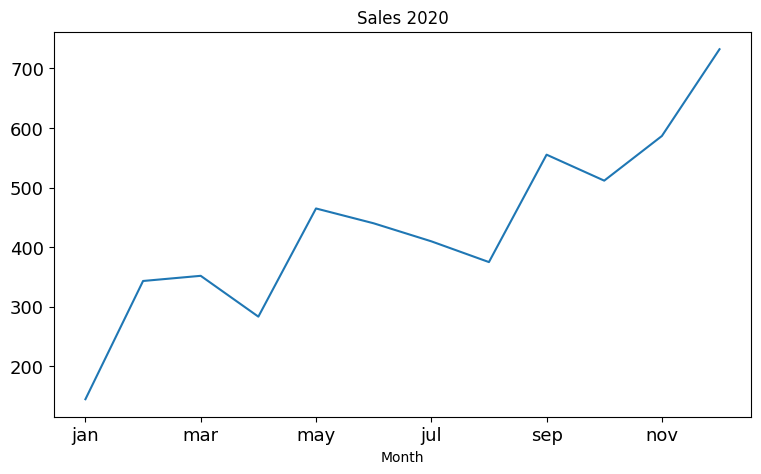

In [4]:
# Line plot, include a title
salesdata["2020"].plot(title="Sales 2020", figsize=(9,5), fontsize=13)
plt.show()

Note: you can experiment with removing the plt.show() command in the code above and below. It many cases the plot will still render. 

We could customise the appearance of this line plot - e.g. add markers, change the line colour and style:

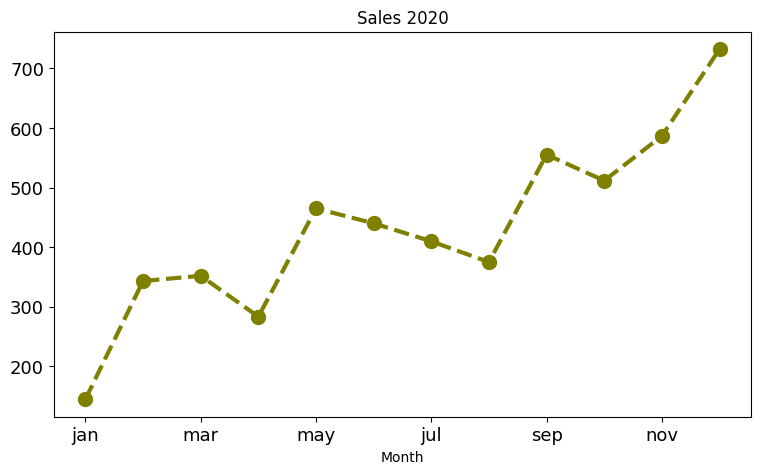

In [5]:
salesdata["2020"].plot(title="Sales 2020", 
                           figsize=(9,5), fontsize=13,
                           marker='o', markersize=10,
                           color='olive', linewidth=3, linestyle='dashed')
plt.show()

We can also plot all years (columns) as lines on the same chart by calling the *plot()* function on the DataFrame. A legend will be automatically included.

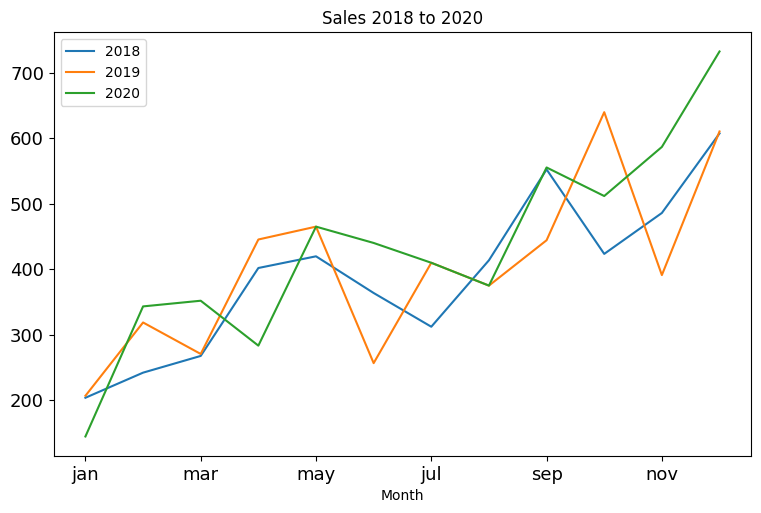

In [6]:
salesdata.plot(title="Sales 2018 to 2020", figsize=(9,5.5), fontsize=13);
plt.show()

Once we have created a plot, we can apply standard Matplotlib methods to customise a plot further. Note this needs to be done in the same Notebook cell.

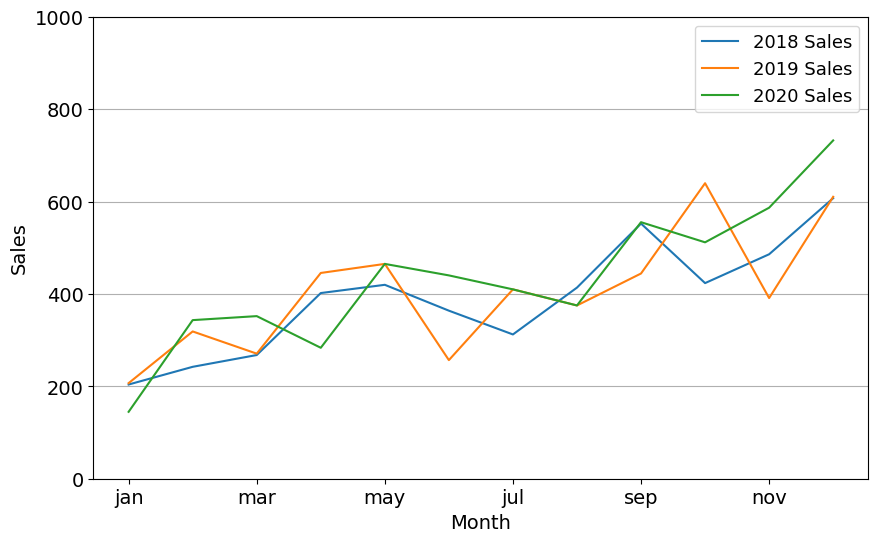

In [7]:
ax = salesdata.plot(figsize=(10,6), fontsize=14)
plt.ylim(0,1000)
plt.grid(axis="y")
plt.legend(["2018 Sales","2019 Sales","2020 Sales"], fontsize=13)
plt.xlabel('Month', fontsize=14)
plt.ylabel('Sales', fontsize=14);
plt.show()

We can display each series on a separate subplot (i.e. **small multiples**) by setting *subplots=True*. We ensure that the y-axes all have the same range using *sharey=True*, so that we can easily make visual comparisons.

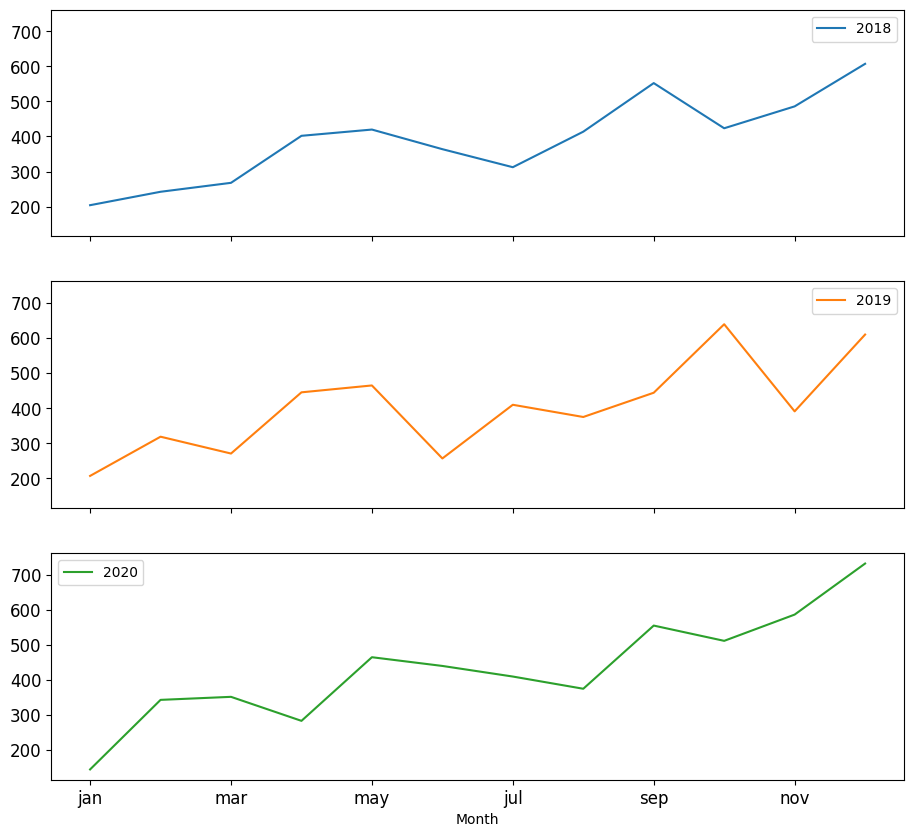

In [8]:
salesdata.plot(subplots=True,figsize=(11, 10), sharey=True, fontsize=12);
plt.show()

## Bar Plots

Create a sample DataFrame with results for 4 assignments submitted by 6 students:

In [9]:
scores = {'first_name': ['John', 'Molly', 'Amy', 'Mary', 'Paul', 'Alice'],
        'assignment1': [15, 10, 23, 16, 9, 11],
        'assignment2': [21, 13, 25, 18, 19, 13],
        'assignment3': [23, 16, 17, 19, 17, 22],
        'assignment4': [18, 18, 19, 19, 18, 20], }
df = pd.DataFrame(scores, columns = ['first_name', 'assignment1', 'assignment2', 'assignment3','assignment4'])
df = df.set_index("first_name")
df

,assignment1,assignment2,assignment3,assignment4
first_name,,,,
John,15,21,23,18
Molly,10,13,16,18
Amy,23,25,17,19
Mary,16,18,19,19
Paul,9,19,17,18
Alice,11,13,22,20


Create a simple vertical bar chart for a single assignment:

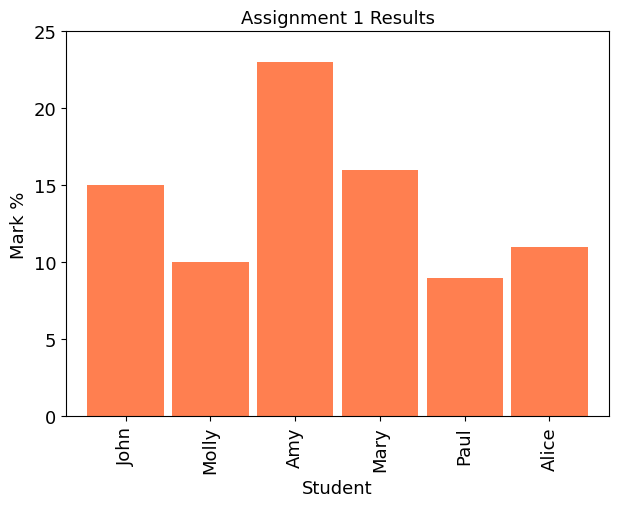

In [10]:
ax = df["assignment1"].plot(kind="bar", figsize=(7, 5), fontsize=13, color="coral", width=0.9)
# customize the axes and title
ax.set_ylim((0,25))
ax.set_xlabel("Student", fontsize=13)
ax.set_ylabel("Mark %", fontsize=13)
ax.set_title("Assignment 1 Results", fontsize=13);
plt.show()

This could also be displayed as a horizontal bar chart:

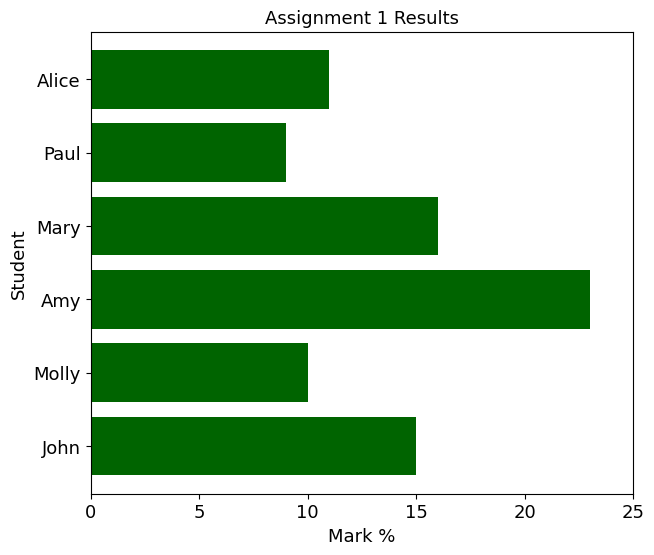

In [11]:
ax = df["assignment1"].plot(kind="barh", figsize=(7, 6), fontsize=13, color="darkgreen", width=0.8)
# customize the axes and title
ax.set_xlim((0,25))
ax.set_xlabel("Mark %", fontsize=13)
ax.set_ylabel("Student", fontsize=13)
ax.set_title("Assignment 1 Results", fontsize=13);
plt.show()

We can also generate bar charts for all assignments (i.e. all columns in the DataFrame):

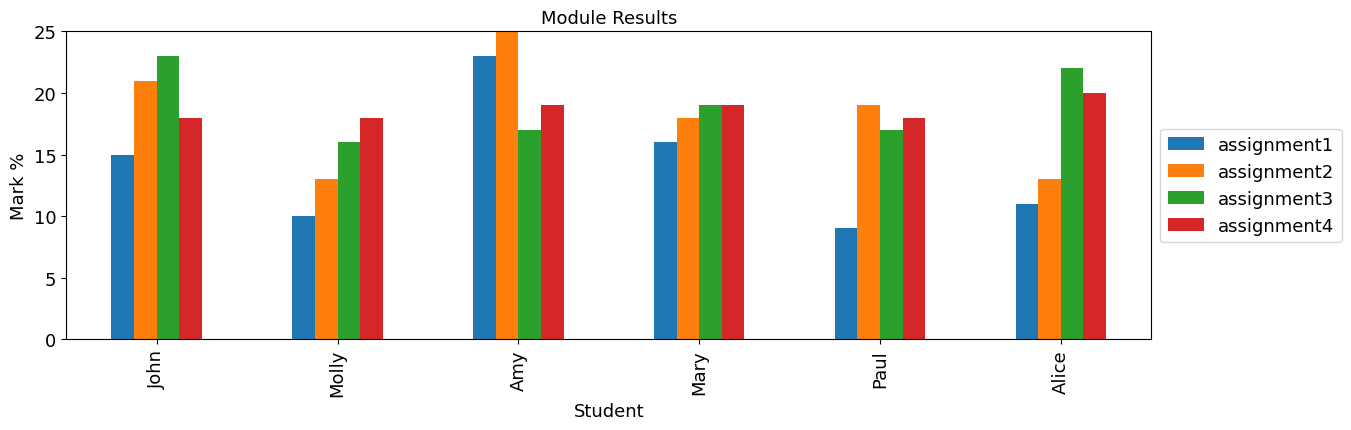

In [12]:
ax = df.plot.bar(figsize=(14, 4), fontsize=13)
# customize the axes and title
ax.set_ylim((0,25))
ax.set_xlabel("Student", fontsize=13)
ax.set_ylabel("Mark %", fontsize=13)
ax.set_title("Module Results", fontsize=13)
# move the legend to outside the plot
ax.legend(loc='center left', bbox_to_anchor=(1.0, 0.5), fontsize=13);
plt.show()

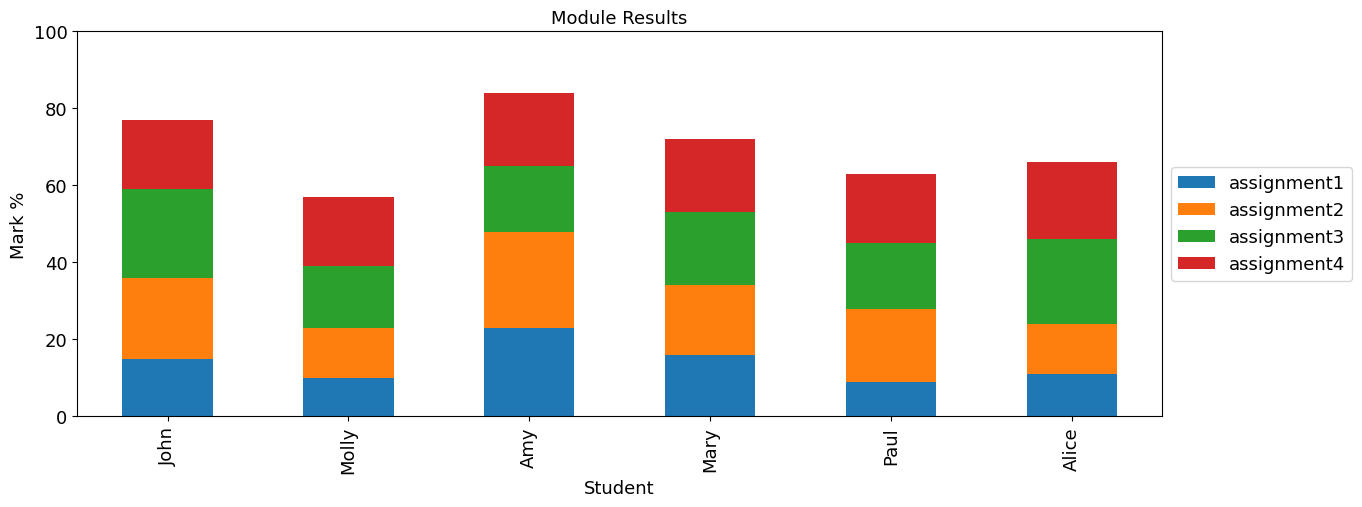

In [13]:
ax = df.plot.bar(stacked=True, figsize=(14, 5), fontsize=13)
# customize the axes and title
ax.set_ylim((0,100))
ax.set_xlabel("Student", fontsize=13)
ax.set_ylabel("Mark %", fontsize=13)
ax.set_title("Module Results", fontsize=13)
# move the legend to outside the plot
ax.legend(loc='center left', bbox_to_anchor=(1.0, 0.5), fontsize=13);
plt.show()

Alternatively, instead of nesting the bars, we can display them as separate subplots:

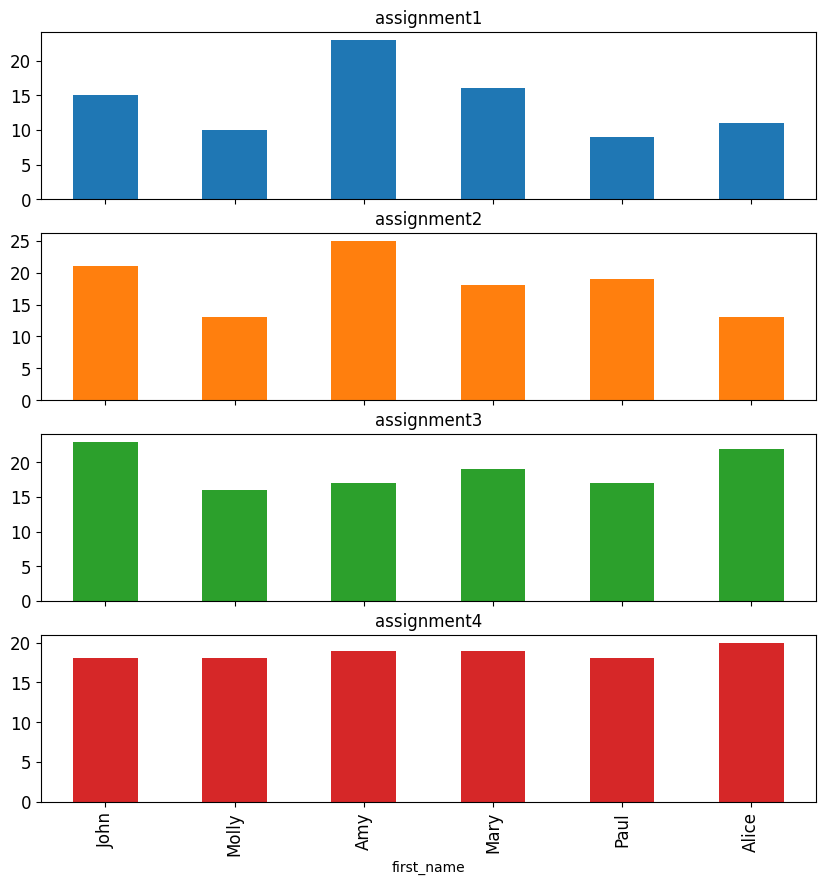

In [14]:
df.plot.bar(figsize=(10, 10), subplots=True, legend=None, fontsize=12);
plt.show()

## Plotting Examples - Penguins Dataset

Here we look at the *penguins* dataset, which is described here:

https://www.kaggle.com/parulpandey/penguin-dataset-the-new-iris

In this dataset, each row represents a set of features describing a penguin, which is categorised by species. We can look at how many penguins are categorised into each species.

In [15]:
data_penguins = pd.read_csv("penguins_af.csv")
data_penguins.head(10)

,Unnamed: 0,species,island,bill_length_mm,bill_depth_mm,flipper_length_mm,body_mass_g,sex,year
0,0,Adelie,Torgersen,39.1,18.7,181.0,3750.0,male,2007
1,1,Adelie,Torgersen,39.5,17.4,186.0,3800.0,female,2007
2,2,Adelie,Torgersen,40.3,18.0,195.0,3250.0,female,2007
3,4,Adelie,Torgersen,36.7,19.3,193.0,3450.0,female,2007
4,5,Adelie,Torgersen,39.3,20.6,190.0,3650.0,male,2007
5,6,Adelie,Torgersen,38.9,17.8,181.0,3625.0,female,2007
6,7,Adelie,Torgersen,39.2,19.6,195.0,4675.0,male,2007
7,12,Adelie,Torgersen,41.1,17.6,182.0,3200.0,female,2007
8,13,Adelie,Torgersen,38.6,21.2,191.0,3800.0,male,2007
9,14,Adelie,Torgersen,34.6,21.1,198.0,4400.0,male,2007


In [16]:
species_counts = data_penguins["species"].value_counts()
species_counts

species
Adelie       146
Gentoo       119
Chinstrap     68
Name: count, dtype: int64

The first way we can plot things is using the *plot()* function from Pandas DataFrames, which uses Matplotlib underneath. We could show the distribution of species visually as a *bar chart*:

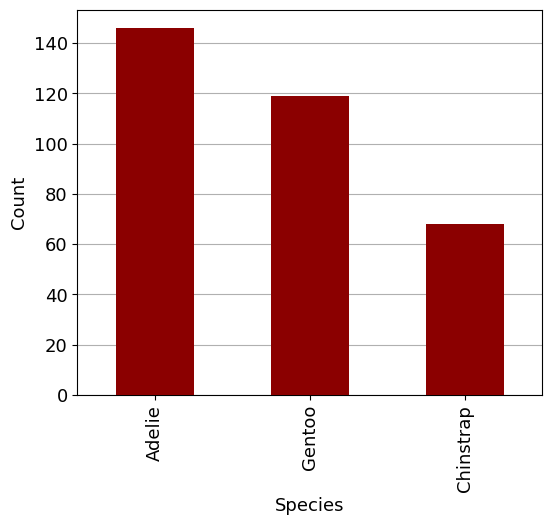

In [17]:
ax = species_counts.plot(kind="bar", fontsize=13, figsize=(6,5), color="darkred", zorder=3)
# add labels to the axes
plt.xlabel("Species", fontsize=13)
plt.ylabel("Count", fontsize=13)
# add horizontal grid lines
ax.yaxis.grid(True);
plt.show()

We could also represent the information above using a *pie chart*:

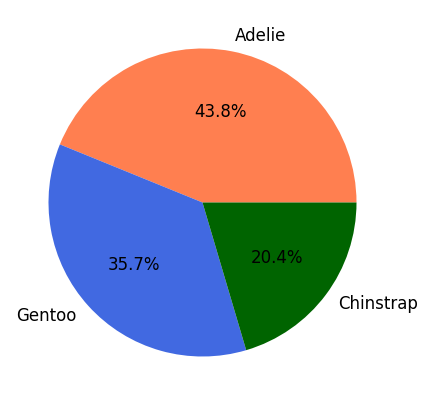

In [18]:
ax = species_counts.plot(kind="pie", figsize=(5, 5), fontsize=12, autopct="%.1f%%", 
                        colors=["coral", "royalblue", "darkgreen"])
ax.set_ylabel(None);
plt.show()

To inspect the relationships between values for different features, we can create a 2D scatterplot of pairs of features in the dataset.

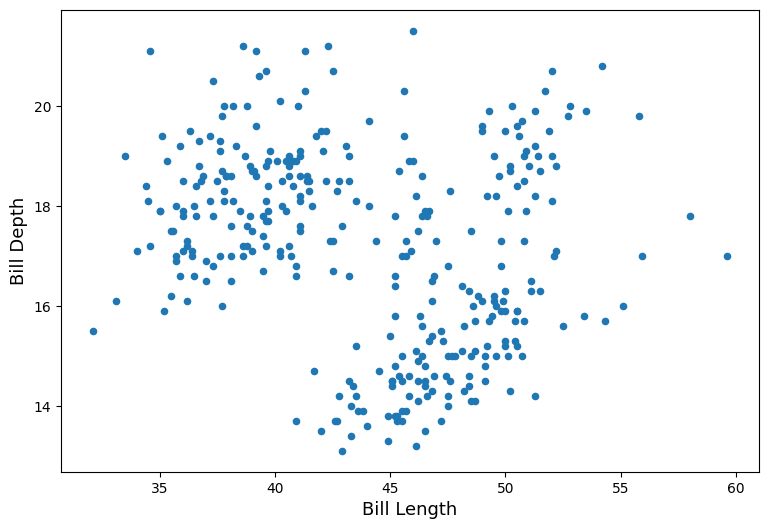

In [19]:
ax = data_penguins.plot(kind="scatter", x="bill_length_mm", y="bill_depth_mm", figsize=(9, 6))
# add axis labels
plt.xlabel('Bill Length', fontsize=13)
plt.ylabel('Bill Depth', fontsize=13);
plt.show()

We customise further aspects of the appearance of the plot, such as the shape and colour of the points:

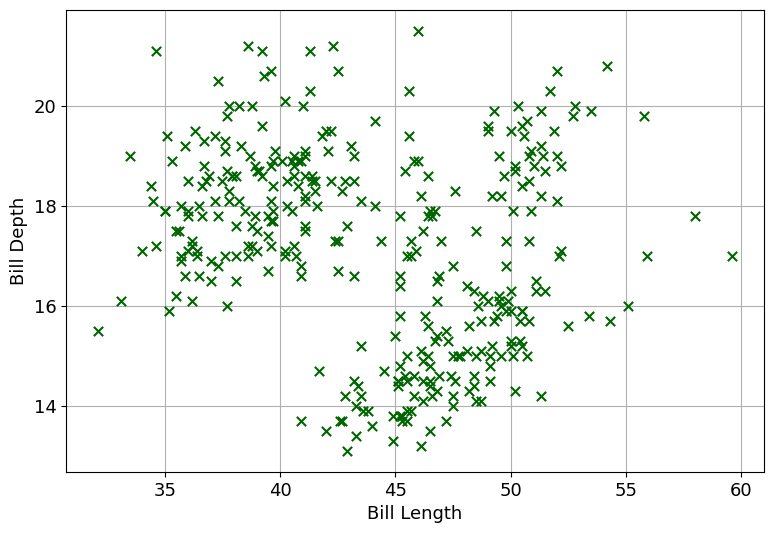

In [20]:
# note the zorder parameter puts the bars in front of the grid
ax = data_penguins.plot(kind="scatter", x="bill_length_mm", y="bill_depth_mm", figsize=(9, 6), fontsize=13,
          marker='x', color='darkgreen', s=45, zorder=3)
# add axis labels
plt.xlabel('Bill Length', fontsize=13)
plt.ylabel('Bill Depth', fontsize=13)
# add horizontal and vertical grid
plt.grid();
plt.show()

To get a view of the distribution of values for a given feature, we can plot a *histogram* with the specified number of "bins":

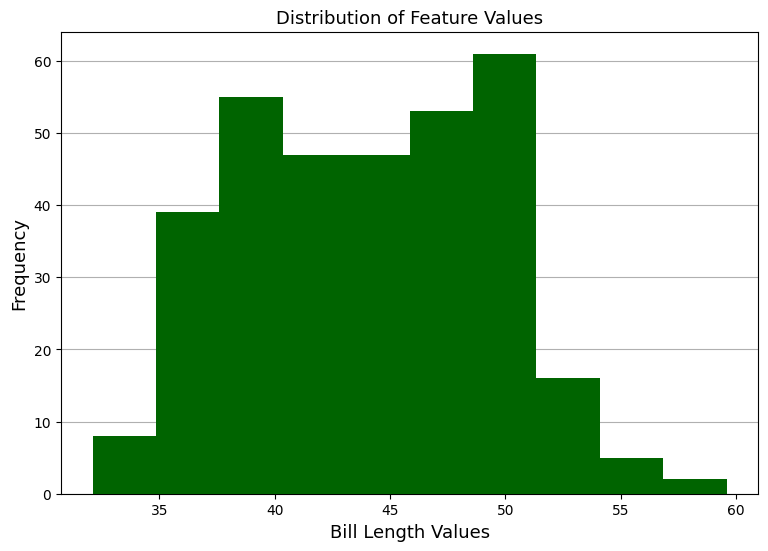

In [21]:
# plot the relevant column as a histogram
ax = data_penguins["bill_length_mm"].hist(bins=10, figsize=(9, 6), color="darkgreen", zorder=3)
plt.grid(axis="x")
plt.title("Distribution of Feature Values", fontsize=13)
plt.xlabel('Bill Length Values', fontsize=13)
plt.ylabel('Frequency', fontsize=13);
plt.show()

<function matplotlib.pyplot.show(close=None, block=None)>

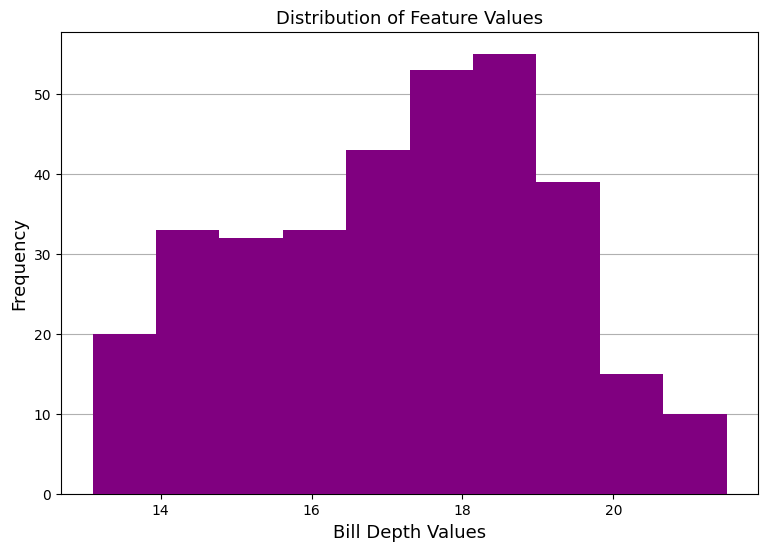

In [22]:
# plot the relevant column as a histogram
ax = data_penguins["bill_depth_mm"].hist(bins=10, figsize=(9, 6), color="purple", zorder=3)
plt.grid(axis="x")
plt.title("Distribution of Feature Values", fontsize=13)
plt.xlabel('Bill Depth Values', fontsize=13)
plt.ylabel('Frequency', fontsize=13);
plt.show